# MobileNet V1

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=3, stride=stride,
            padding=1, groups=in_channels, bias=False,
        )
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.depthwise(x)))
        x = self.relu(self.bn2(self.pointwise(x)))
        return x

In [5]:
def count_conv_params(in_ch, out_ch, kernel_size, groups=1):
    return kernel_size * kernel_size * (in_ch // groups) * out_ch

test_block = DepthwiseSeparableConv(64, 128, stride=1).to(device)
test_input = torch.randn(2, 64, 56, 56).to(device)
test_output = test_block(test_input)
print(f"{test_input.shape} -> {test_output.shape}")

depthwise_params = count_conv_params(64, 64, 3, groups=64)
pointwise_params = count_conv_params(64, 128, 1)
separable_total = depthwise_params + pointwise_params
plain_conv_params = count_conv_params(64, 128, 3)

print(f"\nDepthwise (groups=64): {depthwise_params:,}")
print(f"Pointwise (1x1): {pointwise_params:,}")
print(f"Separable total: {separable_total:,}")
print(f"Plain 3x3 conv (64->128): {plain_conv_params:,}")
print(f"Ratio: {plain_conv_params / separable_total:.1f}x fewer params with separable conv")

torch.Size([2, 64, 56, 56]) -> torch.Size([2, 128, 56, 56])

Depthwise (groups=64): 576
Pointwise (1x1): 8,192
Separable total: 8,768
Plain 3x3 conv (64->128): 73,728
Ratio: 8.4x fewer params with separable conv


In [6]:
class MobileNetV1(nn.Module):

    layer_config = [
        (64, 1),
        (128, 2), (128, 1),
        (256, 2), (256, 1),
        (512, 2),
        (512, 1), (512, 1), (512, 1), (512, 1), (512, 1),
        (1024, 2), (1024, 1),
    ]

    def __init__(self, num_classes=10, width_multiplier=1.0):
        super().__init__()
        alpha = width_multiplier

        def scaled(ch):
            return max(8, int(ch * alpha))

        self.stem = nn.Sequential(
            nn.Conv2d(3, scaled(32), kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(scaled(32)),
            nn.ReLU(inplace=True),
        )

        layers = []
        in_channels = scaled(32)
        for out_channels, stride in self.layer_config:
            out_channels = scaled(out_channels)
            layers.append(DepthwiseSeparableConv(in_channels, out_channels, stride=stride))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(in_channels, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.fc(x)

model = MobileNetV1(num_classes=10, width_multiplier=1.0).to(device)
print(model)

MobileNetV1(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (features): Sequential(
    (0): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [7]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [8]:
def count_conv_params(in_ch, out_ch, kernel_size, groups=1):
    return kernel_size * kernel_size * (in_ch // groups) * out_ch

def count_bn_params(num_features):
    return 2 * num_features

def count_separable_block(in_ch, out_ch):
    depthwise = count_conv_params(in_ch, in_ch, 3, groups=in_ch)
    bn1 = count_bn_params(in_ch)
    pointwise = count_conv_params(in_ch, out_ch, 1)
    bn2 = count_bn_params(out_ch)
    return depthwise + bn1 + pointwise + bn2

stem_conv = count_conv_params(3, 32, 3)
stem_bn = count_bn_params(32)
manual_total = stem_conv + stem_bn

in_ch = 32
for out_ch, stride in model.layer_config:
    manual_total += count_separable_block(in_ch, out_ch)
    in_ch = out_ch

fc_params = (in_ch + 1) * 10
manual_total += fc_params

torch_total = sum(p.numel() for p in model.parameters())

print(f"Manual total: {manual_total:,}")
print(f"torch total:  {torch_total:,}")
assert manual_total == torch_total, "Mismatch in total parameter count"

Manual total: 3,217,226
torch total:  3,217,226


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.1362 train_acc=0.2212 | val_loss=2.0518 val_acc=0.2665 | time=60.1s
Epoch 2/10 | train_loss=1.9855 train_acc=0.2963 | val_loss=1.8454 val_acc=0.3432 | time=57.2s
Epoch 3/10 | train_loss=1.8087 train_acc=0.3774 | val_loss=1.6990 val_acc=0.4181 | time=57.6s
Epoch 4/10 | train_loss=1.6647 train_acc=0.4344 | val_loss=1.5353 val_acc=0.4818 | time=57.8s
Epoch 5/10 | train_loss=1.5584 train_acc=0.4701 | val_loss=1.3680 val_acc=0.5488 | time=57.8s
Epoch 6/10 | train_loss=1.4760 train_acc=0.5062 | val_loss=1.3705 val_acc=0.5427 | time=57.8s
Epoch 7/10 | train_loss=1.4110 train_acc=0.5297 | val_loss=1.2486 val_acc=0.5857 | time=58.0s
Epoch 8/10 | train_loss=1.3734 train_acc=0.5451 | val_loss=1.2284 val_acc=0.5987 | time=58.0s
Epoch 9/10 | train_loss=1.3321 train_acc=0.5610 | val_loss=1.1439 val_acc=0.6268 | time=57.8s
Epoch 10/10 | train_loss=1.2957 train_acc=0.5661 | val_loss=1.1223 val_acc=0.6349 | time=57.8s


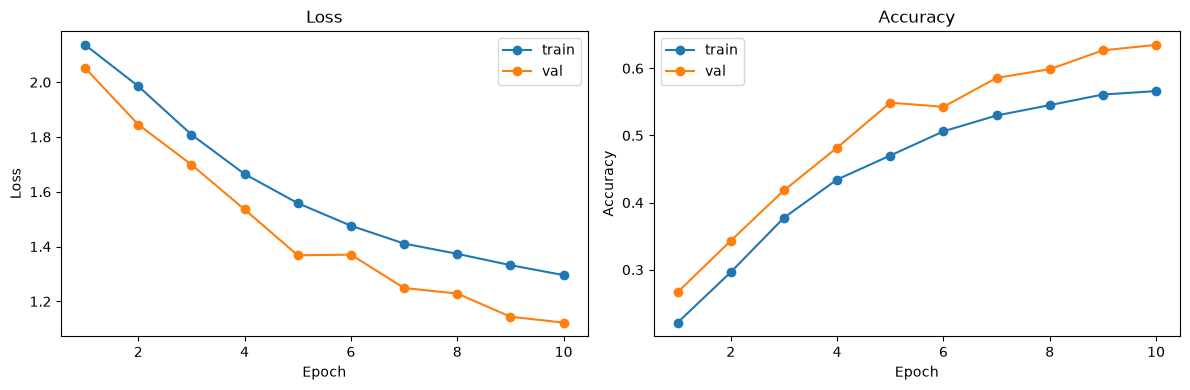

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

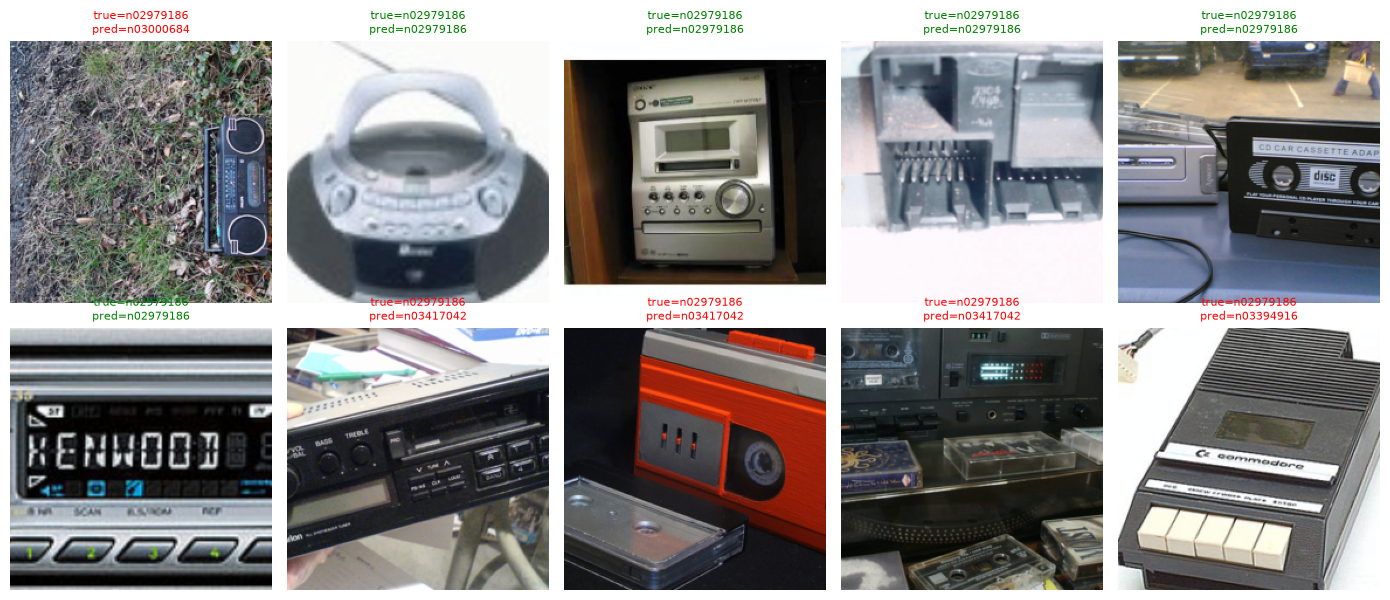

In [13]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: ~3M -
substantially fewer than any architecture in this repository so far
(~3M vs. ResNet-18's ~11M or DenseNet-121's ~7-8M), despite comparable
depth, because every 3x3 convolution except the very first is factored
into a depthwise (groups=in_channels) + pointwise (1x1) pair, cutting
parameters roughly 8-9x per layer relative to a plain 3x3 convolution at
the same channel counts (see manual comparison above).

**Depthwise conv as the extreme case of grouped convolution.** This is the
groups=in_channels special case we flagged as a question at the end of the
ResNeXt notes - taking cardinality to its logical extreme, where every
"group" is exactly one channel. The tradeoff: depthwise conv alone cannot
mix information across channels at all (each channel is processed in total
isolation), which is why it must always be paired with a pointwise 1x1
conv immediately after - that's the only place channel mixing happens in
this architecture.

**Why Adam instead of RMSProp.** The original paper used RMSProp with
asynchronous gradient descent, similar to how AlexNet was trained. We used
Adam for simpler, more reliable convergence without manual tuning.